In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
data = sns.load_dataset('mpg')

In [4]:
data.shape

(398, 9)

In [5]:
data.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [6]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


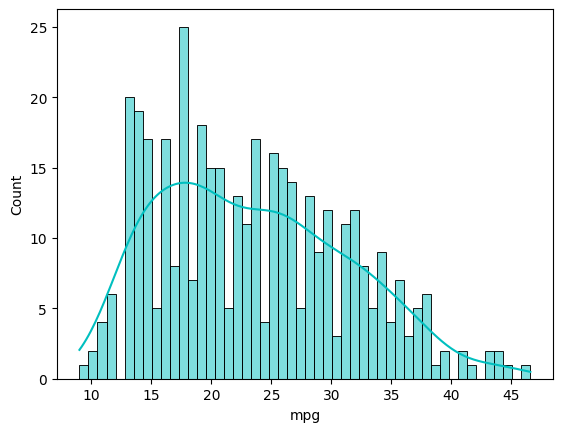

In [7]:
sns.histplot(data['mpg'], kde=True, color='c', bins=50)
plt.show()

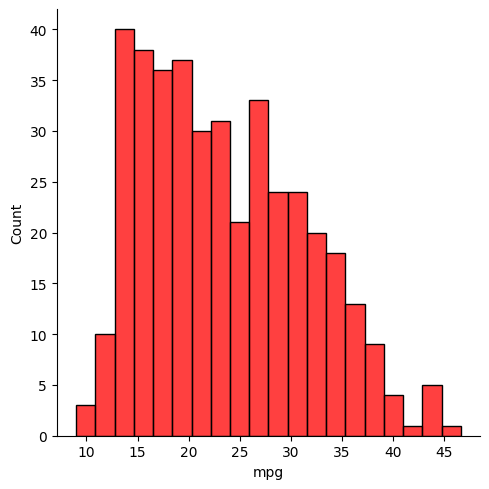

In [8]:
sns.displot(data['mpg'], kde=False,rug = False, color='r', bins=20)
plt.show()

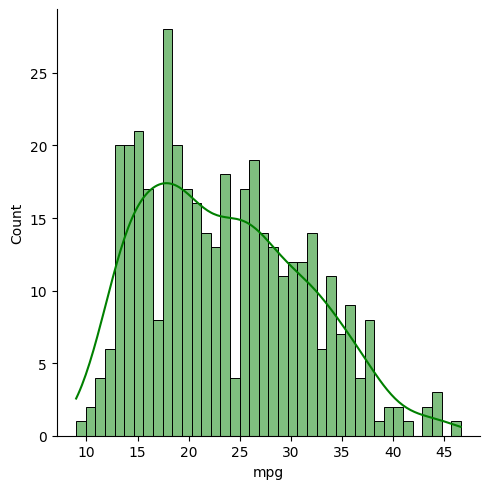

In [9]:
sns.displot(data['mpg'], kde=True,rug = False, color='g', bins=40,alpha=0.5)
plt.show()

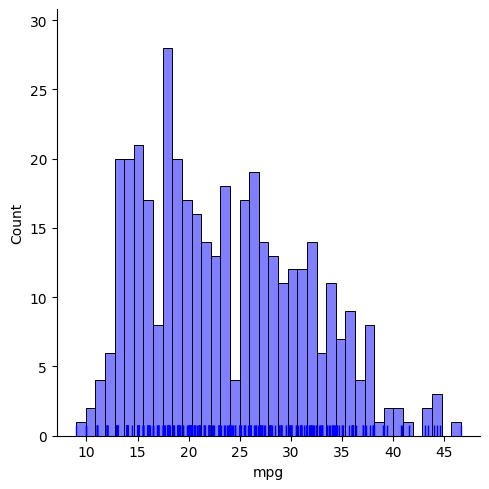

In [10]:
sns.displot(data['mpg'], kde=False,rug = True, color='b', bins=40,alpha=0.5)
plt.show()

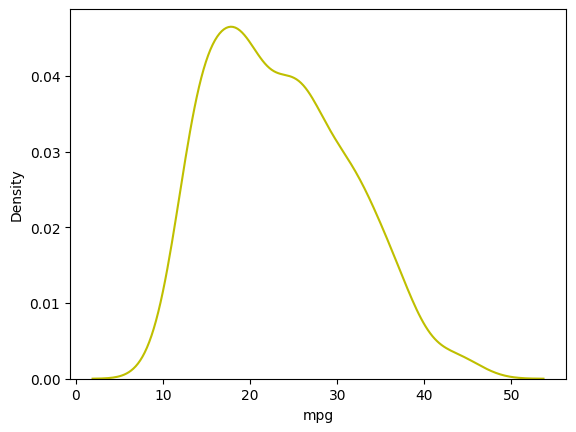

In [11]:
sns.kdeplot(data['mpg'], color='y')
plt.show()

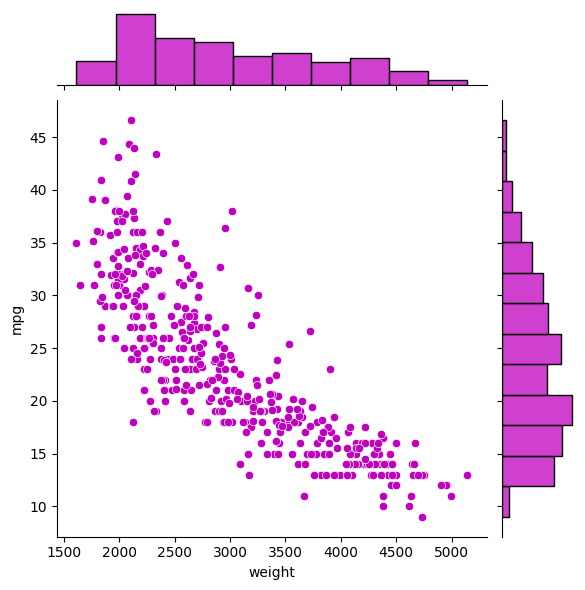

In [12]:
sns.jointplot(x ='weight', y ='mpg', data = data, kind ='scatter', color='m')
plt.show()

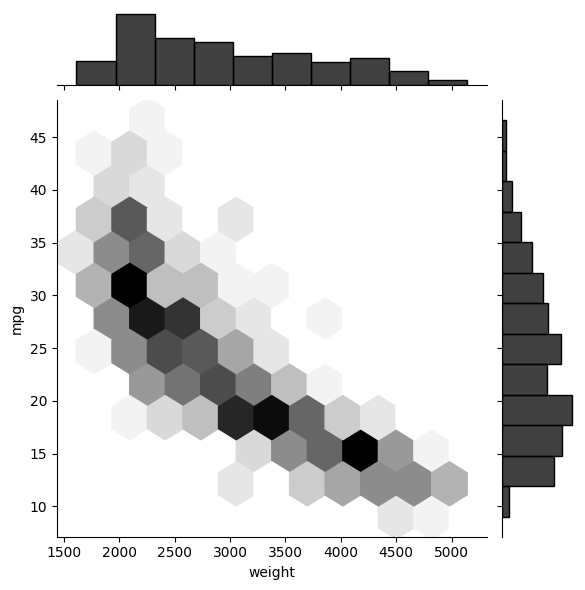

In [13]:
sns.jointplot(x ='weight', y ='mpg', data = data, kind ='hex', color='k')
plt.show()


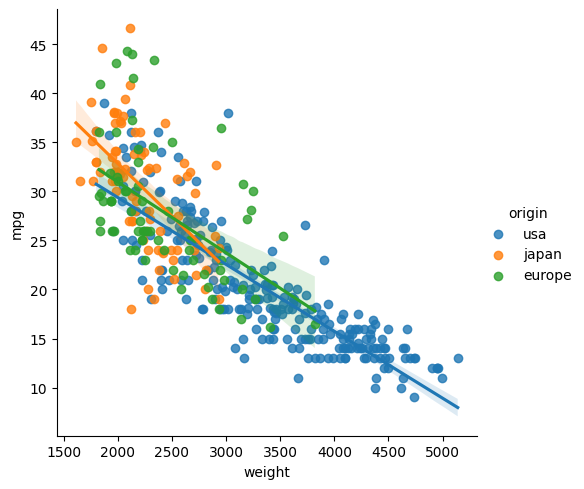

In [14]:
sns.lmplot(x ='weight', y ='mpg', data = data, hue ='origin')
plt.show()

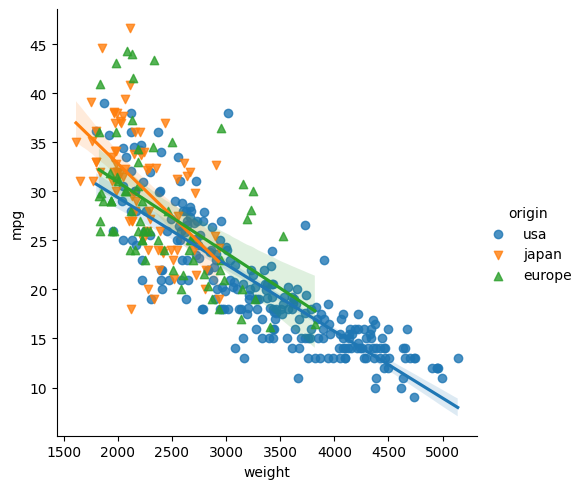

In [15]:
sns.lmplot(x ='weight', y ='mpg', data = data, hue ='origin', markers=['o','v','^'])
plt.show()

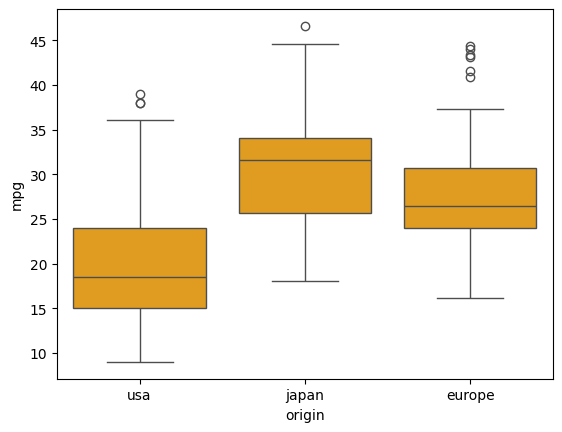

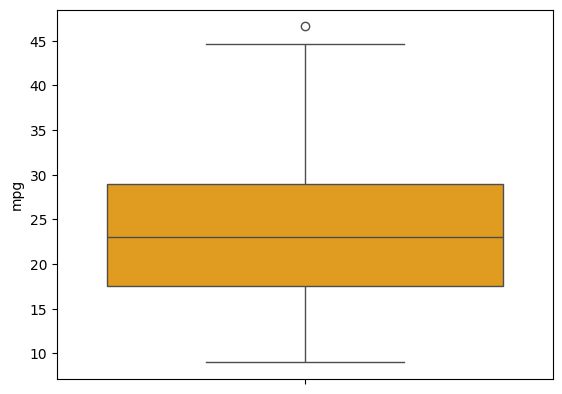

In [16]:
sns.boxplot(x='origin', y='mpg', data=data, color='orange')
plt.show()
sns.boxplot(y='mpg', data=data, color='orange')
plt.show()

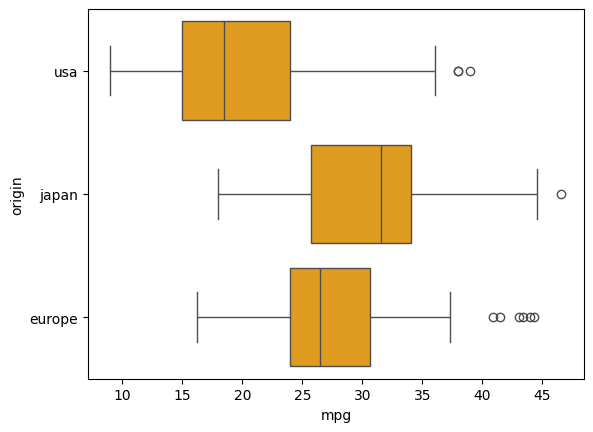

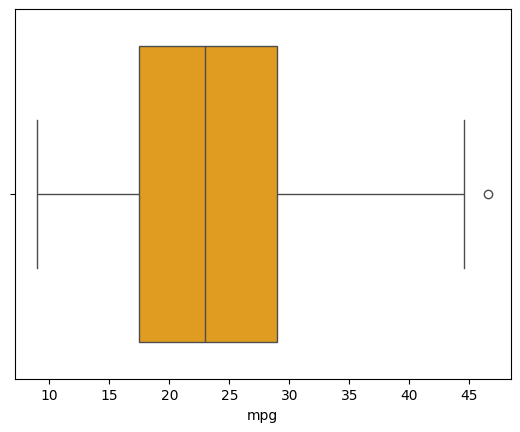

In [17]:
sns.boxplot(x='mpg', y='origin', data=data, color='orange')
plt.show()
sns.boxplot(x='mpg', data=data, color='orange')
plt.show()

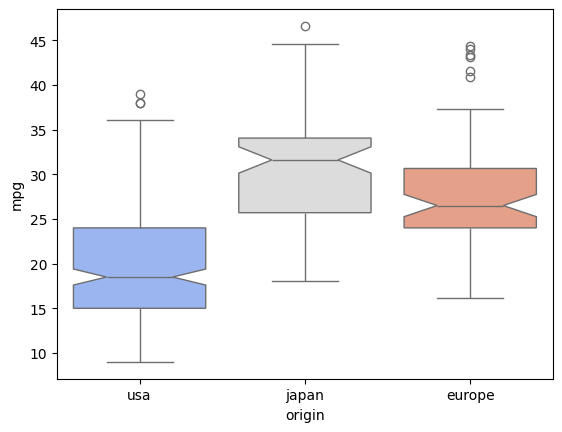

In [18]:
sns.boxplot(x='origin', y='mpg', data=data, palette='coolwarm', notch=True)
plt.show()

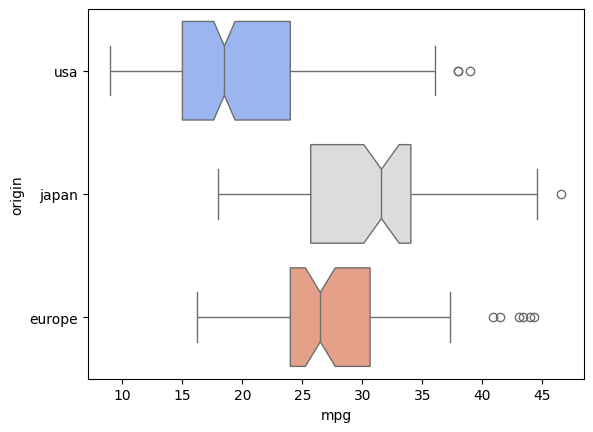

In [19]:
sns.boxplot(x='mpg', y='origin', data=data, palette='coolwarm', notch=True)
plt.show()

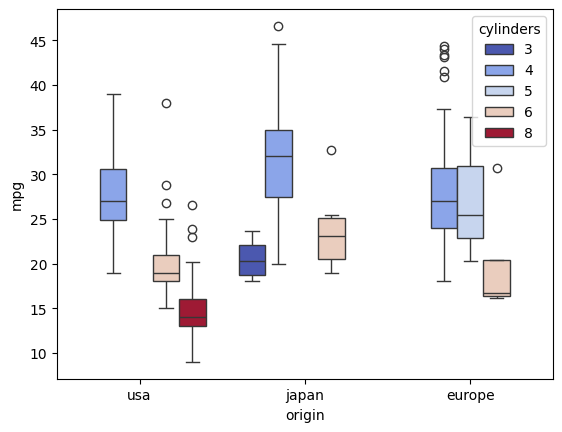

In [20]:
sns.boxplot(x='origin', y='mpg', data=data, hue='cylinders', palette='coolwarm')
plt.show()

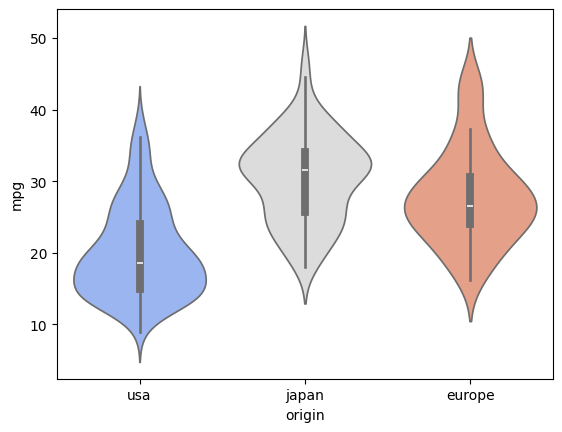

In [21]:
sns.violinplot(x='origin', y='mpg', data=data, palette='coolwarm')
plt.show()

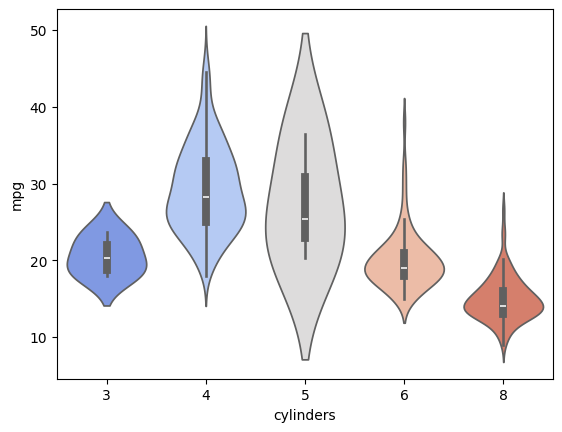

In [22]:
sns.violinplot(x='cylinders', y='mpg', data=data, palette='coolwarm')
plt.show()

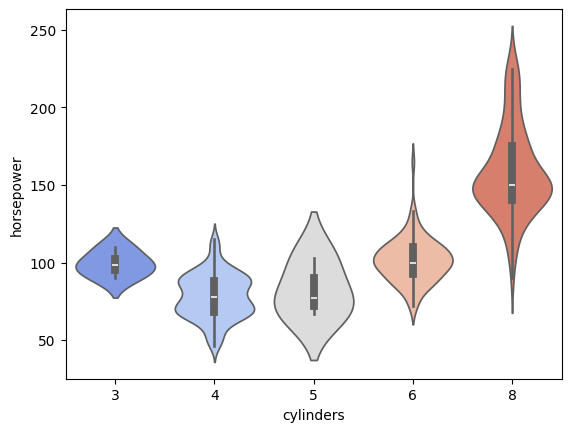

In [23]:
sns.violinplot(x='cylinders', y='horsepower', data=data, palette='coolwarm')
plt.show()

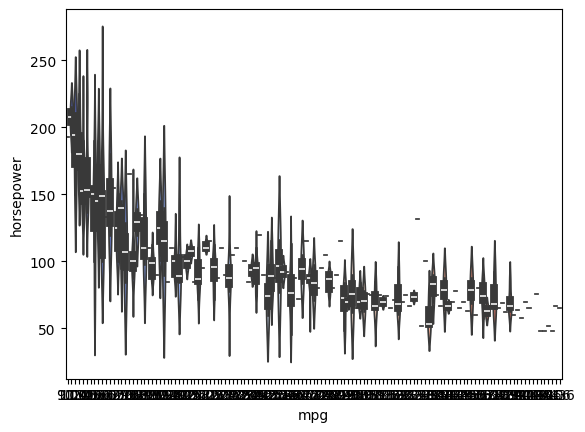

In [24]:
sns.violinplot(x='mpg', y='horsepower', data=data, palette='coolwarm')
plt.show()

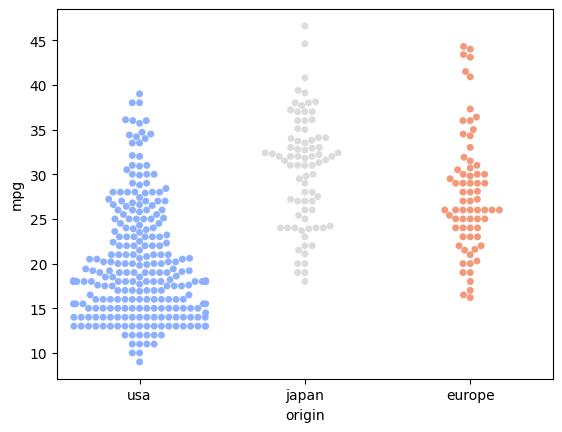

In [25]:
sns.swarmplot(x='origin', y='mpg', data=data, palette='coolwarm')
plt.show()

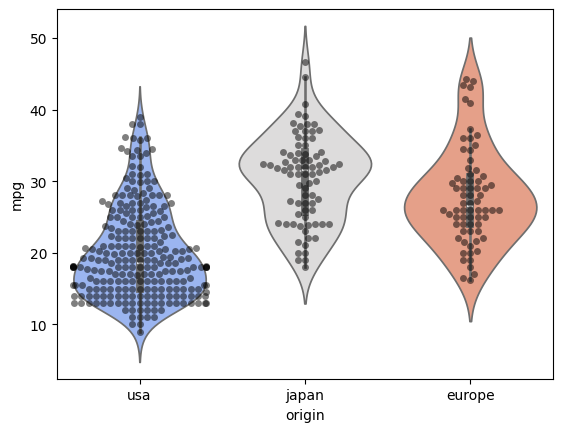

In [26]:
sns.violinplot(x='origin', y='mpg', data=data, palette='coolwarm')
sns.swarmplot(x='origin', y='mpg', data=data, color='k', alpha=0.5)
plt.show()

In [27]:
df = sns.load_dataset('iris')

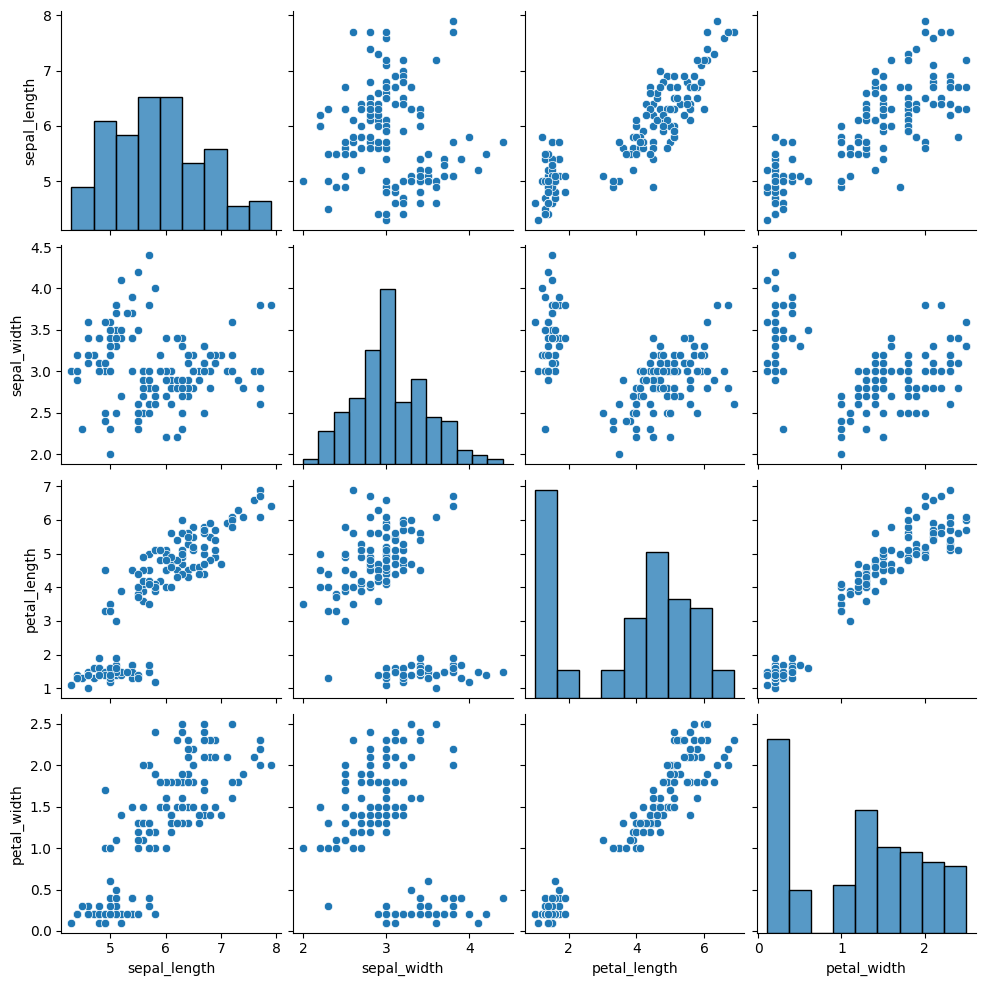

In [28]:
sns.pairplot(df)
plt.show()

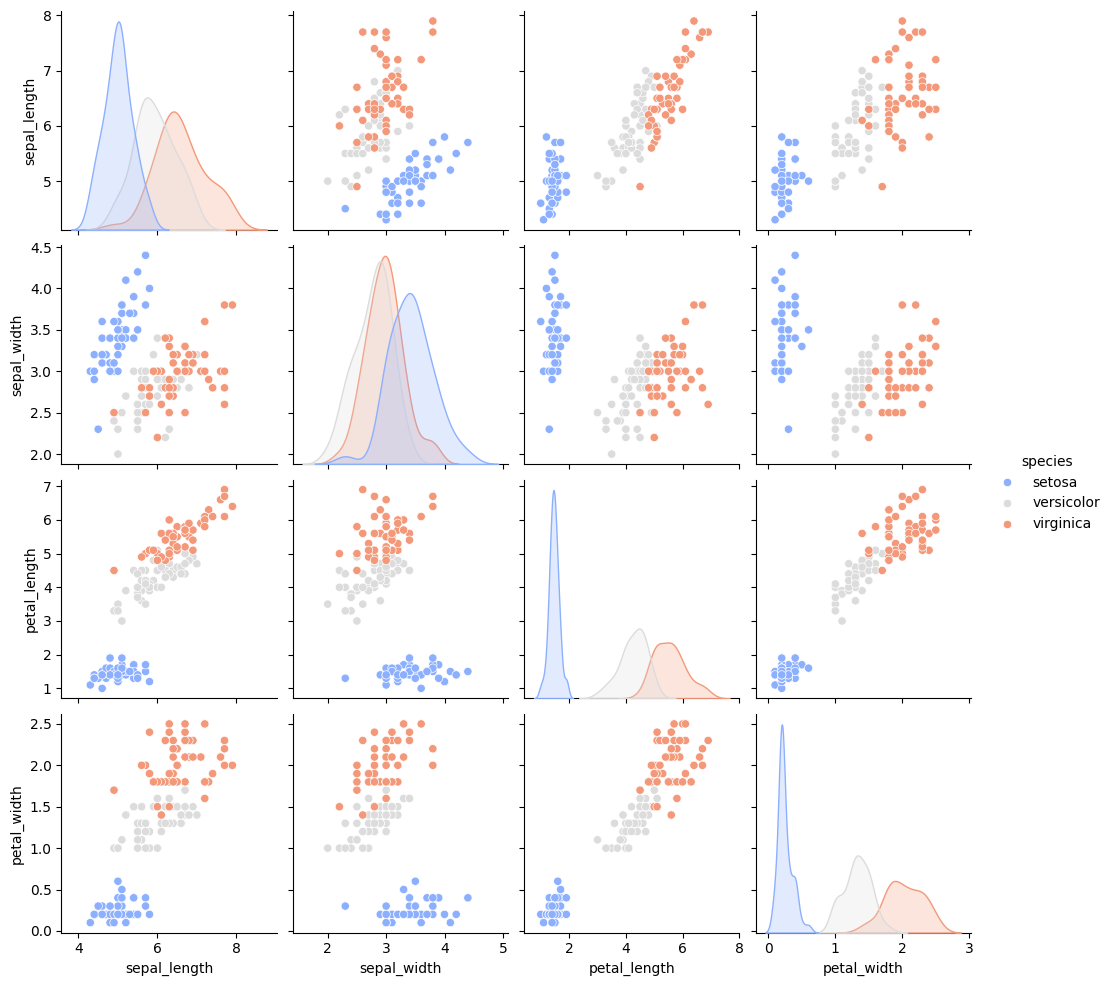

In [29]:
sns.pairplot(df, hue='species', palette='coolwarm')
plt.show()

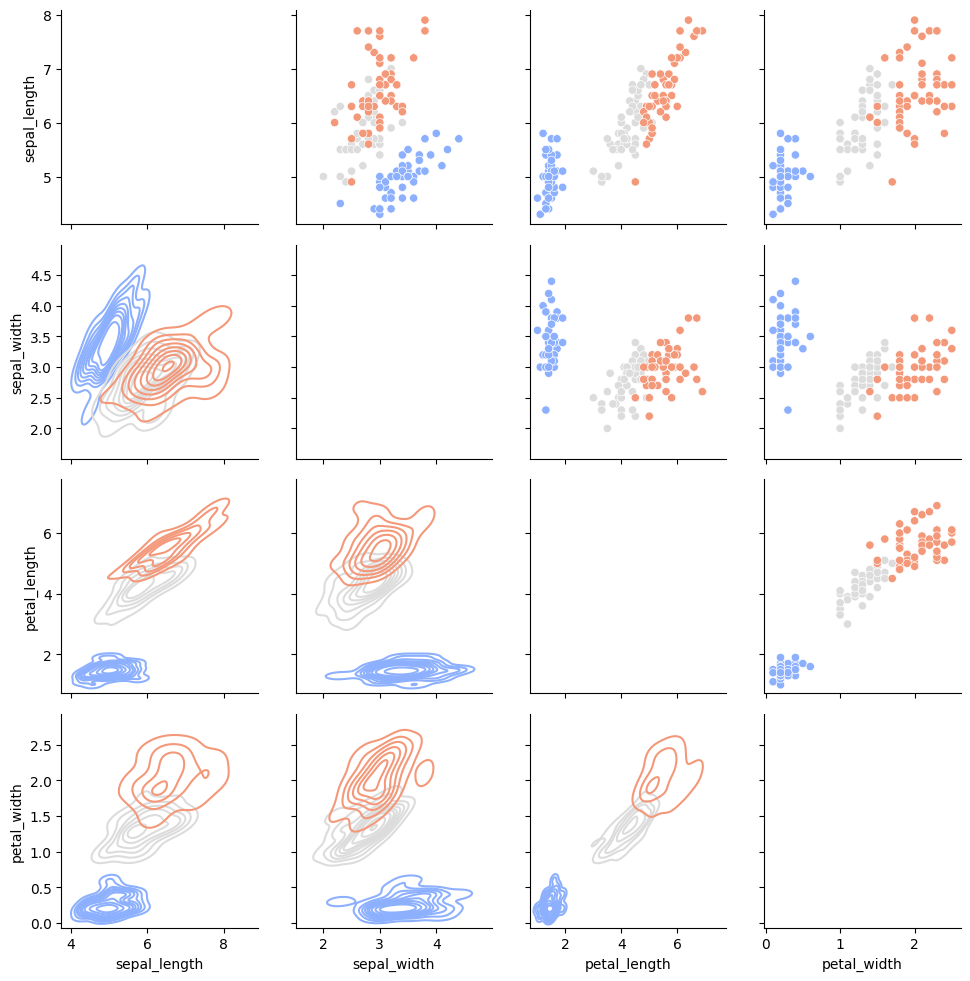

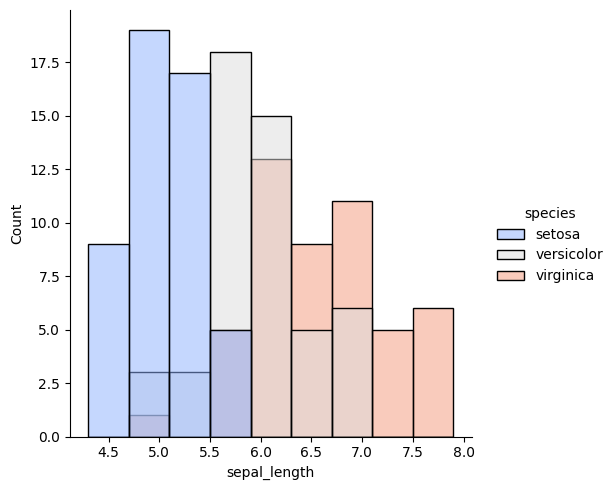

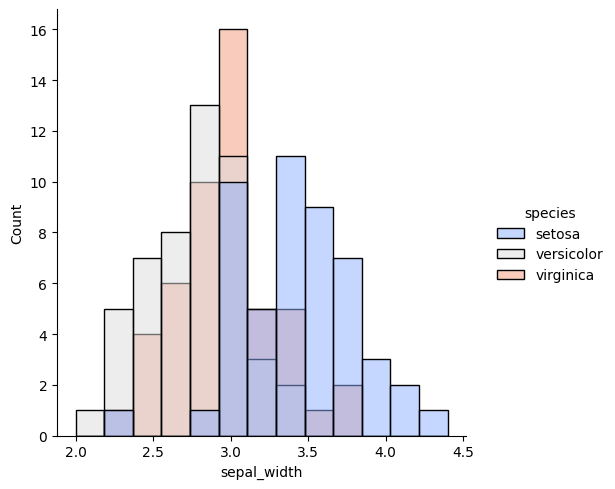

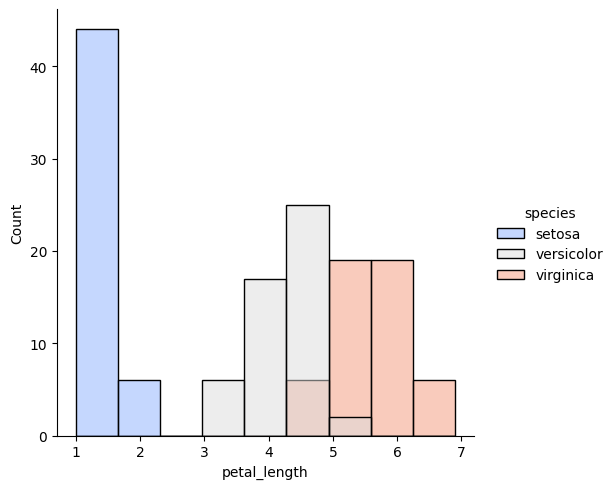

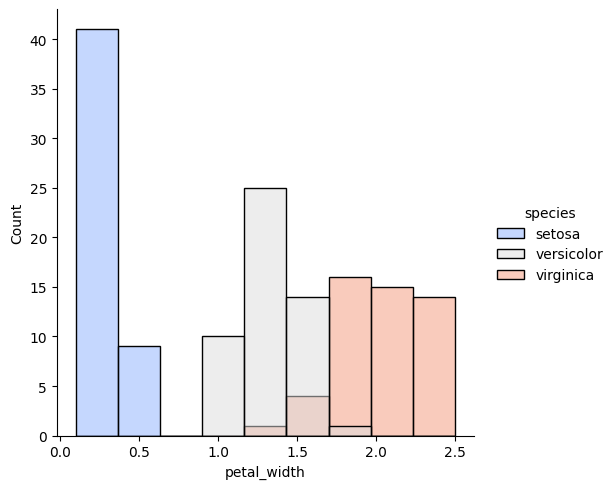

In [30]:
g = sns.PairGrid(df, hue='species', palette='coolwarm')
g.map_diag(sns.displot, color='m')
g.map_upper(sns.scatterplot, color='c')
g.map_lower(sns.kdeplot, color='b')
plt.show()

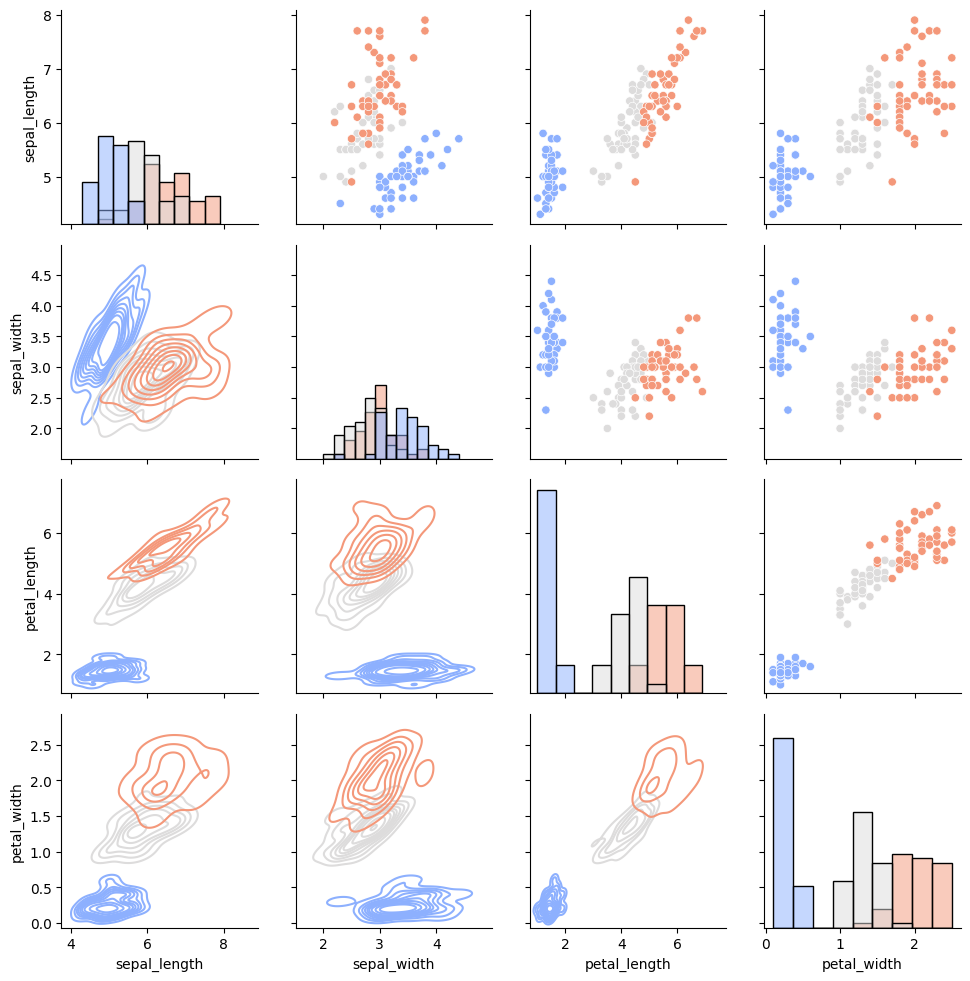

In [31]:
g = sns.PairGrid(df, hue='species', palette='coolwarm')
g.map_diag(sns.histplot, color='m')
g.map_upper(sns.scatterplot, color='c')
g.map_lower(sns.kdeplot, color='b')
plt.show()

In [32]:
def piechar_iris(feature_names, target, dataset):
    i = 1
    plt.figure(figsize=(20,15))
    for colName in [target]:
        labels = []; size = [];
        df = dataset.groupby(colName).size()
        for key in df.keys():
            labels.append(key)
            size.append(df[key])
        plt.subplot(2,2,i)
        plt.axis('on')
        plt.tick_params(axis = 'both', bottom = True, top = False, left = True, right = False, labelbottom = False, labelleft = True, labeltop = True, labelright = False)
        plt.pie(size, labels=labels, autopct='%1.1f%%', startangle=140,shadow=True)
        plt.axis('equal')
        i += 1
    plt.show()

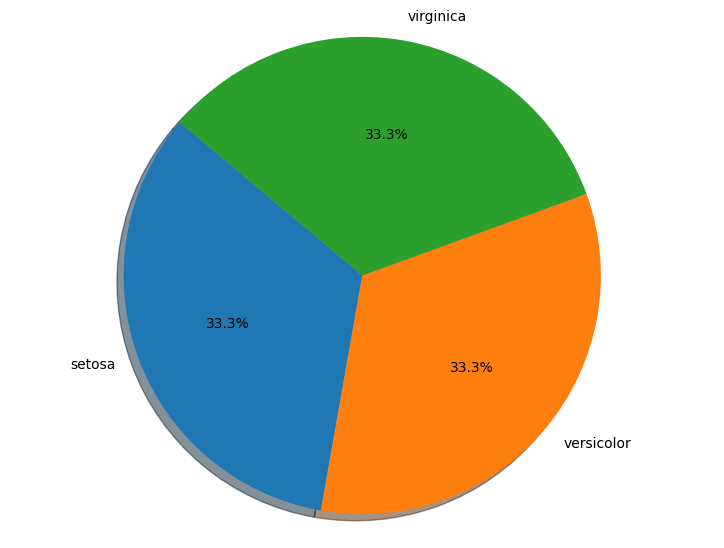

In [33]:
piechar_iris(df.columns[:-1], 'species', df)

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [35]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df.iloc[:,-1], test_size=0.2, random_state=42)

In [36]:
model = DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=3, min_samples_split=2, 
                               min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, 
                               random_state=42, max_leaf_nodes=None, min_impurity_decrease=0.0, 
                               class_weight=None)

In [37]:
##
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [38]:
##Performance Evaluation --> Score refers to accuracy for classification models
model.score(X_test, y_test)

1.0

In [39]:
##Cross validation --> split the data into k parts and train and test the model k times
from sklearn.model_selection import cross_val_score, KFold
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
results = cross_val_score(model, X_train, y_train, cv=kfold)
final_results = results.mean()

In [40]:
for i, score in enumerate(results):
    print("{}th cross validation score: {}".format(i, score))
print("\nCross validation final mean score: {}".format(final_results))

0th cross validation score: 0.8333333333333334
1th cross validation score: 1.0
2th cross validation score: 1.0
3th cross validation score: 1.0
4th cross validation score: 0.8333333333333334
5th cross validation score: 1.0
6th cross validation score: 0.75
7th cross validation score: 0.75
8th cross validation score: 1.0
9th cross validation score: 1.0

Cross validation final mean score: 0.9166666666666667


In [41]:
for i, score in enumerate(results):
    print(f"Fold {i+1}: {score:.4f}")
print(f"Average Cross-Validation Score: {final_results:.4f}")

Fold 1: 0.8333
Fold 2: 1.0000
Fold 3: 1.0000
Fold 4: 1.0000
Fold 5: 0.8333
Fold 6: 1.0000
Fold 7: 0.7500
Fold 8: 0.7500
Fold 9: 1.0000
Fold 10: 1.0000
Average Cross-Validation Score: 0.9167


In [42]:
!pip install git+https://github.com/reiinakano/scikit-plot.git

  Cloning https://github.com/reiinakano/scikit-plot.git to c:\users\admin\appdata\local\temp\pip-req-build-kulhegmd
  Resolved https://github.com/reiinakano/scikit-plot.git to commit 2dd3e6a76df77edcbd724c4db25575f70abb57cb
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/reiinakano/scikit-plot.git 'C:\Users\admin\AppData\Local\Temp\pip-req-build-kulhegmd'


In [43]:
%pip install scikit-plot

Note: you may need to restart the kernel to use updated packages.


In [1]:
import scikitplot as skplt

ImportError: cannot import name 'interp' from 'scipy' (c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\__init__.py)

In [ ]:
import matplotlib.pyplot as plt
skplt.estimators.plot_learning_curve(model, X_train, y_train,figsize=(6,6))
plt.show()

NameError: name 'skplt' is not defined